In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, optimizers

IMG_SIZE = 64
base_dir = 'animals_small'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Data...")
train_generator = train_datagen.flow_from_directory(
    f'{base_dir}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    f'{base_dir}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)
# Helper to train and return history
def train_model(model, train_gen, test_gen, epochs=20, name="Model"):
    print(f"\n--- Training {name} ---")
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=test_gen,
        verbose=1
    )
    return history

# ==========================================
# MODEL 1: MACHINE LEARNING (Logistic Regression)
# ==========================================
# Implementation: A Neural Network with 0 hidden layers is mathematically 
# identical to Multinomial Logistic Regression.
# Input Size: 64x64 (Flattened)

print("\nSetting up Logistic Regression Data (64x64)...")
train_gen_lr = train_datagen_aug.flow_from_directory(
    f'{base_dir}/train', target_size=(64, 64), batch_size=32, class_mode='categorical')
test_gen_lr = test_datagen.flow_from_directory(
    f'{base_dir}/test', target_size=(64, 64), batch_size=32, class_mode='categorical', shuffle=False)
# (2669165)
model_lr = models.Sequential([
    layers.Flatten(input_shape=(64, 64, 3)),
    # No hidden layers = Linear Classifier
    layers.Dense(3, activation='softmax') 
], name="Logistic_Regression")

model_lr.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_lr = train_model(model_lr, train_gen_lr, test_gen_lr, epochs=20, name="Logistic Regression")


# ==========================================
# MODEL 2: ANN (Artificial Neural Network)
# ==========================================
# Implementation: Flatten -> Dense (Hidden) -> Output
# Input Size: 64x64

model_ann = models.Sequential([
    layers.Flatten(input_shape=(64, 64, 3)),
    
    # Hidden Layer 1
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Hidden Layer 2
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Output Layer
    layers.Dense(3, activation='softmax')
], name="ANN")

model_ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_ann = train_model(model_ann, train_gen_lr, test_gen_lr, epochs=20, name="ANN")


# ==========================================
# MODEL 3: CNN (Convolutional Neural Network)
# ==========================================
# Implementation: Conv2D -> MaxPool -> Dense -> Output
# Input Size: 200x200 (CNNs handle larger images better)

print("\nSetting up CNN Data (200x200)...")
train_gen_cnn = train_datagen_aug.flow_from_directory(
    f'{base_dir}/train', target_size=(200, 200), batch_size=32, class_mode='categorical')
test_gen_cnn = test_datagen.flow_from_directory(
    f'{base_dir}/test', target_size=(200, 200), batch_size=32, class_mode='categorical', shuffle=False)

model_cnn = models.Sequential([
    # Feature Extraction
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Classification Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Regularization
    layers.Dense(3, activation='softmax')
], name="CNN")

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_cnn = train_model(model_cnn, train_gen_cnn, test_gen_cnn, epochs=20, name="CNN")

Loading Data...
Found 1281 images belonging to 3 classes.
Found 321 images belonging to 3 classes.

Setting up Logistic Regression Data (64x64)...
Found 1281 images belonging to 3 classes.
Found 321 images belonging to 3 classes.

--- Training Logistic Regression ---


c:\Users\viren\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.4052 - loss: 1.7100 - val_accuracy: 0.4766 - val_loss: 1.0003
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.4145 - loss: 1.3161 - val_accuracy: 0.5047 - val_loss: 1.0112
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.4504 - loss: 1.1319 - val_accuracy: 0.4393 - val_loss: 1.0823
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.4551 - loss: 1.2448 - val_accuracy: 0.4860 - val_loss: 1.0084
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.4356 - loss: 1.3140 - val_accuracy: 0.5607 - val_loss: 0.9864
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.4809 - loss: 1.3537 - val_accuracy: 0.5576 - val_loss: 0.9777
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.4223 - loss: 1.3262 - val_accuracy: 0.4860 - val_loss: 1.6099
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.4434 - loss: 1.2378 - val_accuracy: 0.

c:\Users\viren\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 35s 818ms/step - accuracy: 0.4754 - loss: 1.1309 - val_accuracy: 0.5950 - val_loss: 0.8090
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 936ms/step - accuracy: 0.5558 - loss: 0.8973 - val_accuracy: 0.6012 - val_loss: 0.8271
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 905ms/step - accuracy: 0.5636 - loss: 0.8332 - val_accuracy: 0.6324 - val_loss: 0.7435
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 829ms/step - accuracy: 0.5917 - loss: 0.7923 - val_accuracy: 0.6168 - val_loss: 0.7853
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 35s 863ms/step - accuracy: 0.6058 - loss: 0.7914 - val_accuracy: 0.5888 - val_loss: 0.8258
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 914ms/step - accuracy: 0.5948 - loss: 0.7968 - val_accuracy: 0.6729 - val_loss: 0.6840
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 38s 927ms/step - accuracy: 0.6448 - loss: 0.7400 - val_accuracy: 0.6417 - val_loss: 0.7697
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 37s 904ms/step - accuracy: 0.6393 - loss: 0.7148 - val_accu


EVALUATION: Logistic Regression
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        cats       0.40      0.09      0.15       107
        dogs       0.42      0.91      0.57       107
       panda       0.90      0.53      0.67       107

    accuracy                           0.51       321
   macro avg       0.57      0.51      0.46       321
weighted avg       0.57      0.51      0.46       321



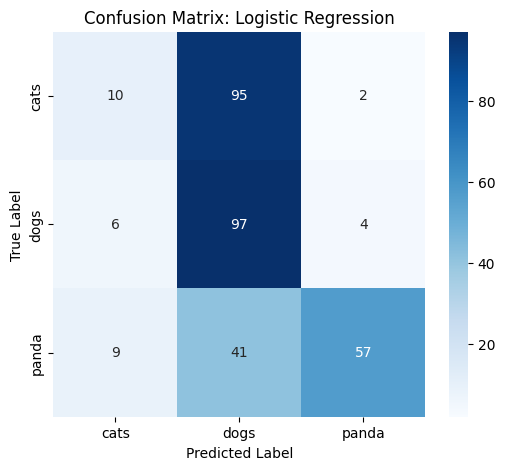


EVALUATION: ANN
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        cats       0.59      0.54      0.56       107
        dogs       0.52      0.50      0.51       107
       panda       0.76      0.86      0.81       107

    accuracy                           0.63       321
   macro avg       0.62      0.63      0.63       321
weighted avg       0.62      0.63      0.63       321



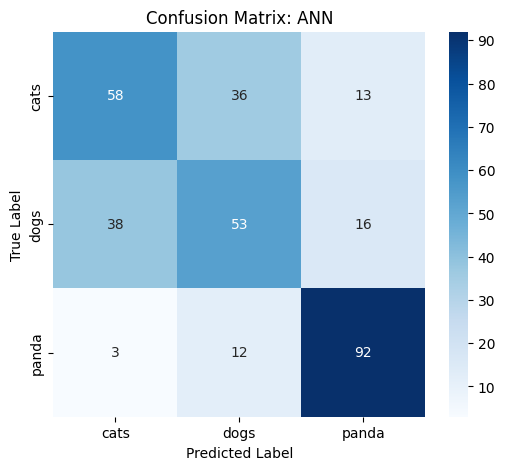


EVALUATION: CNN
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 226ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        cats       0.64      0.76      0.70       107
        dogs       0.75      0.40      0.52       107
       panda       0.77      0.99      0.87       107

    accuracy                           0.72       321
   macro avg       0.72      0.72      0.69       321
weighted avg       0.72      0.72      0.69       321



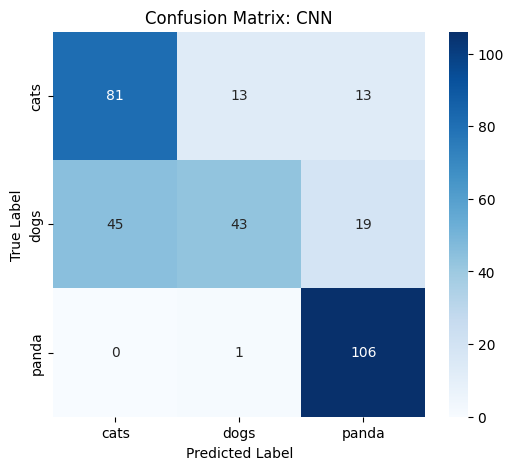

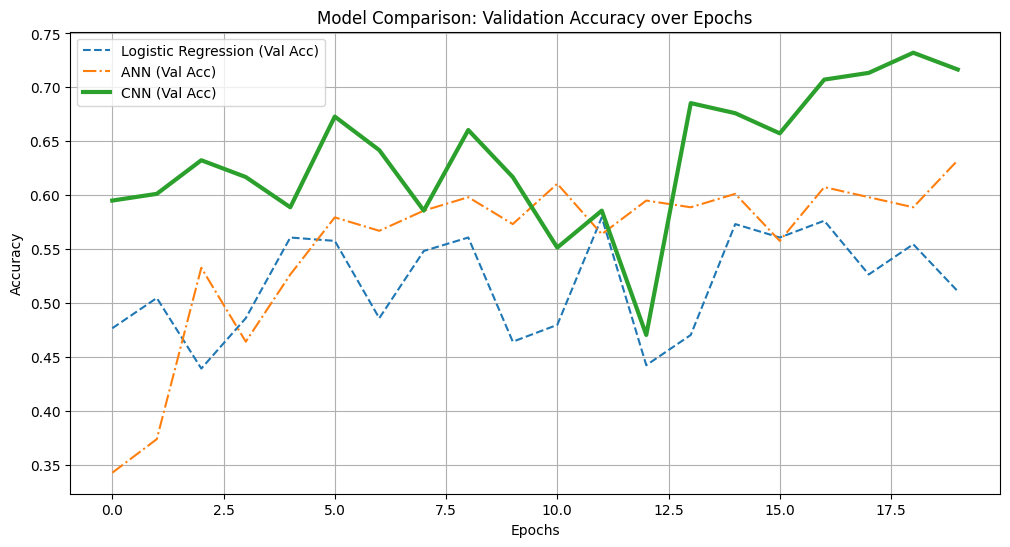

Comparison Complete. Use these plots and metrics for the 'Critical Analysis' section of your report.


In [4]:
# ==========================================
# EVALUATION FUNCTION
# ==========================================
def evaluate_model(model, generator, model_name):
    print(f"\n{'='*40}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*40}")
    
    # 1. Predictions
    # Reset generator to start
    generator.reset()
    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())

    # 2. Classification Report (Precision, Recall, F1)
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 3. Confusion Matrix Plot
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run Evaluation for all three
evaluate_model(model_lr, test_gen_lr, "Logistic Regression")
evaluate_model(model_ann, test_gen_lr, "ANN")
evaluate_model(model_cnn, test_gen_cnn, "CNN")

# ==========================================
# COMPARISON PLOT
# ==========================================
plt.figure(figsize=(12, 6))

plt.plot(hist_lr.history['val_accuracy'], label='Logistic Regression (Val Acc)', linestyle='--')
plt.plot(hist_ann.history['val_accuracy'], label='ANN (Val Acc)', linestyle='-.')
plt.plot(hist_cnn.history['val_accuracy'], label='CNN (Val Acc)', linewidth=3)

plt.title('Model Comparison: Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("Comparison Complete. Use these plots and metrics for the 'Critical Analysis' section of your report.")

Calculating metrics for all models... (This may take a moment)


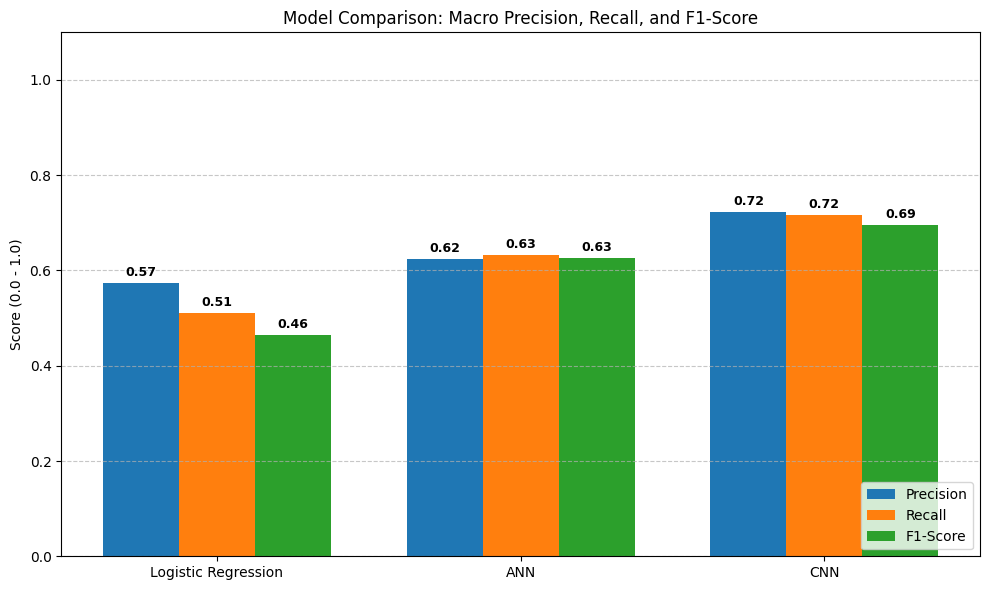

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# ==========================================
# 1. HELPER FUNCTION TO GET METRICS
# ==========================================
def get_macro_metrics(model, generator):
    # Reset generator to ensure order
    generator.reset()
    
    # Get predictions
    predictions = model.predict(generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    # Calculate Macro metrics (average of all classes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro'
    )
    return precision, recall, f1

print("Calculating metrics for all models... (This may take a moment)")

# ==========================================
# 2. CALCULATE METRICS
# ==========================================
# Ensure you pass the correct generator (LR/ANN use resized 64x64, CNN uses 200x200)

# Logistic Regression
p_lr, r_lr, f1_lr = get_macro_metrics(model_lr, test_gen_lr)

# ANN
p_ann, r_ann, f1_ann = get_macro_metrics(model_ann, test_gen_lr)

# CNN
p_cnn, r_cnn, f1_cnn = get_macro_metrics(model_cnn, test_gen_cnn)

# Prepare data for plotting
models = ['Logistic Regression', 'ANN', 'CNN']
precision_scores = [p_lr, p_ann, p_cnn]
recall_scores = [r_lr, r_ann, r_cnn]
f1_scores = [f1_lr, f1_ann, f1_cnn]

# ==========================================
# 3. PLOT THE BAR CHART
# ==========================================
x = np.arange(len(models))  # Label locations
width = 0.25                # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
rects1 = ax.bar(x - width, precision_scores, width, label='Precision', color='#1f77b4') # Blue
rects2 = ax.bar(x, recall_scores, width, label='Recall', color='#ff7f0e')        # Orange
rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#2ca02c')  # Green

# Add text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score (0.0 - 1.0)')
ax.set_title('Model Comparison: Macro Precision, Recall, and F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1) # Set y-axis limit slightly above 1 for text space
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Function to add labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

Evaluating models to get final accuracy...


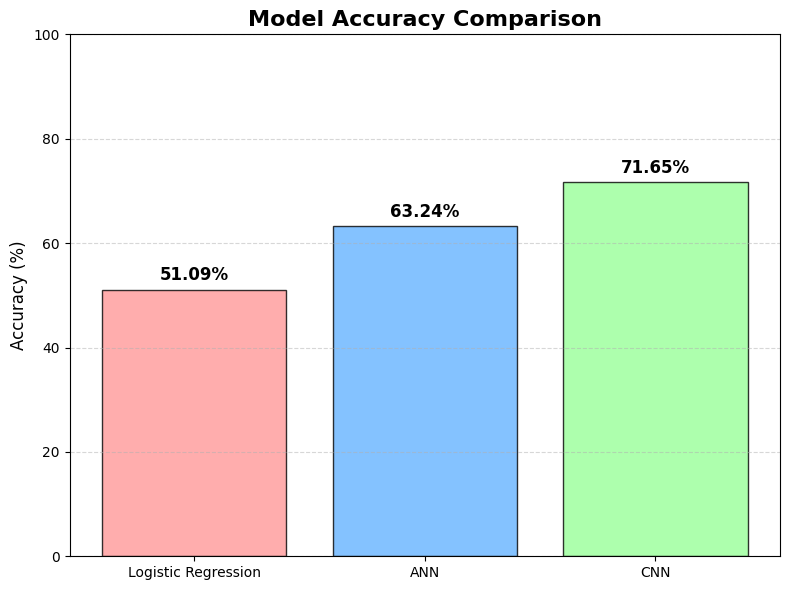

In [6]:
import matplotlib.pyplot as plt

# ==========================================
# 1. GET ACCURACY SCORES
# ==========================================
print("Evaluating models to get final accuracy...")

# Note: We use verbose=0 to hide the progress bar output
_, acc_lr = model_lr.evaluate(test_gen_lr, verbose=0)
_, acc_ann = model_ann.evaluate(test_gen_lr, verbose=0)
_, acc_cnn = model_cnn.evaluate(test_gen_cnn, verbose=0)

# Convert to percentages
scores = [acc_lr * 100, acc_ann * 100, acc_cnn * 100]
model_names = ['Logistic Regression', 'ANN', 'CNN']
colors = ['#ff9999', '#66b3ff', '#99ff99'] # Red, Blue, Green

# ==========================================
# 2. PLOT THE BAR CHART
# ==========================================
plt.figure(figsize=(8, 6))

# Create bars
bars = plt.bar(model_names, scores, color=colors, edgecolor='black', alpha=0.8)

# Add title and labels
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100) # Scale from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 1, 
                 f'{height:.2f}%', 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

add_labels(bars)

# Show the plot
plt.tight_layout()
plt.show()

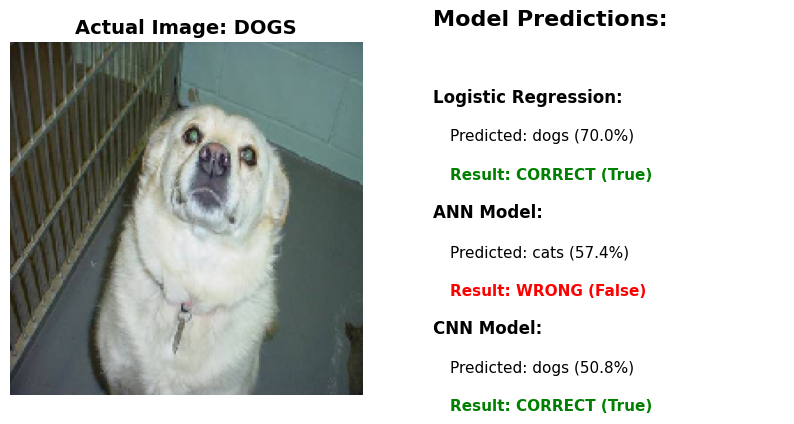

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

# ==========================================
# CONFIGURATION
# ==========================================
test_dir = 'animals_small/test'
class_names = ['cats', 'dogs', 'panda'] # 0, 1, 2

def test_single_image():
    # 1. Pick a random image from the test folder
    # ------------------------------------------
    random_class = random.choice(class_names)
    class_path = os.path.join(test_dir, random_class)
    
    # Safety check if folder exists
    if not os.path.exists(class_path):
        print(f"Path not found: {class_path}")
        return

    random_file = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_file)
    true_label = random_class

    # 2. Preprocess the image for different models
    # ------------------------------------------
    
    # A. Preprocess for CNN (Needs 200x200)
    img_cnn_obj = image.load_img(img_path, target_size=(200, 200))
    img_cnn = image.img_to_array(img_cnn_obj)
    img_cnn = np.expand_dims(img_cnn, axis=0) # Make batch
    img_cnn /= 255.0  # Normalize

    # B. Preprocess for Logistic & ANN (Needs 64x64)
    img_flat_obj = image.load_img(img_path, target_size=(64, 64))
    img_flat = image.img_to_array(img_flat_obj)
    img_flat = np.expand_dims(img_flat, axis=0) # Make batch
    img_flat /= 255.0  # Normalize

    # 3. Make Predictions
    # ------------------------------------------
    # verbose=0 hides the progress bar output
    pred_lr_probs = model_lr.predict(img_flat, verbose=0)
    pred_ann_probs = model_ann.predict(img_flat, verbose=0)
    pred_cnn_probs = model_cnn.predict(img_cnn, verbose=0)

    # 4. Helper to decode prediction
    # ------------------------------------------
    def decode_pred(probs):
        idx = np.argmax(probs)
        label = class_names[idx]
        conf = probs[0][idx]
        return label, conf

    lr_label, lr_conf = decode_pred(pred_lr_probs)
    ann_label, ann_conf = decode_pred(pred_ann_probs)
    cnn_label, cnn_conf = decode_pred(pred_cnn_probs)

    # 5. Visualize Results
    # ------------------------------------------
    plt.figure(figsize=(10, 5))
    
    # Show the image on the left
    plt.subplot(1, 2, 1)
    plt.imshow(img_cnn_obj)
    plt.axis('off')
    plt.title(f"Actual Image: {true_label.upper()}", fontsize=14, fontweight='bold')

    # Show text results on the right
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    # Y-position for text
    y_pos = 0.8
    
    plt.text(0, 1.0, "Model Predictions:", fontsize=16, fontweight='bold')
    
    # Loop through models to print results
    results = [
        ("Logistic Regression", lr_label, lr_conf),
        ("ANN Model", ann_label, ann_conf),
        ("CNN Model", cnn_label, cnn_conf)
    ]
    
    for model_name, pred_label, conf in results:
        # Determine Color (Green if True, Red if False)
        if pred_label == true_label:
            result_text = "CORRECT (True)"
            color = 'green'
        else:
            result_text = "WRONG (False)"
            color = 'red'
            
        # Print Model Name
        plt.text(0, y_pos, f"{model_name}:", fontsize=12, fontweight='bold')
        # Print Prediction details
        plt.text(0.05, y_pos - 0.1, f"Predicted: {pred_label} ({conf:.1%})", fontsize=11)
        # Print True/False Verdict
        plt.text(0.05, y_pos - 0.2, f"Result: {result_text}", fontsize=11, color=color, fontweight='bold')
        
        y_pos -= 0.3 # Move down for next model

    plt.show()

# Run the function (Run this cell multiple times to see different images)
test_single_image()

Loading test images into memory...
Found 321 images belonging to 3 classes.
Loaded 321 test images.


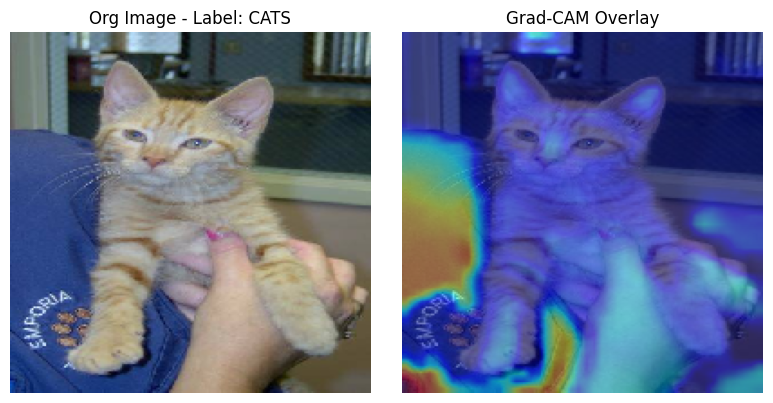

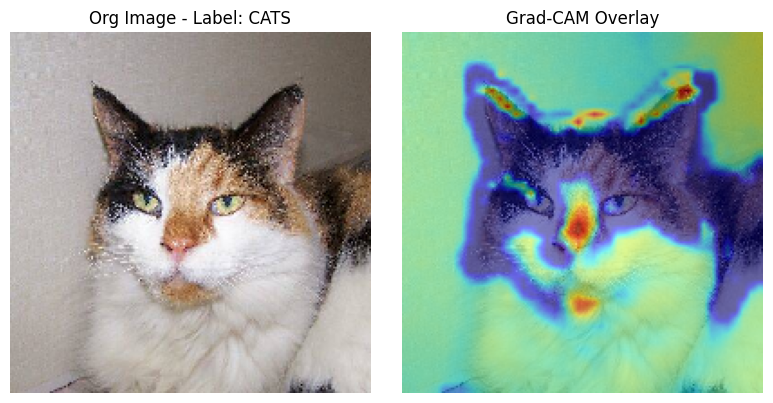

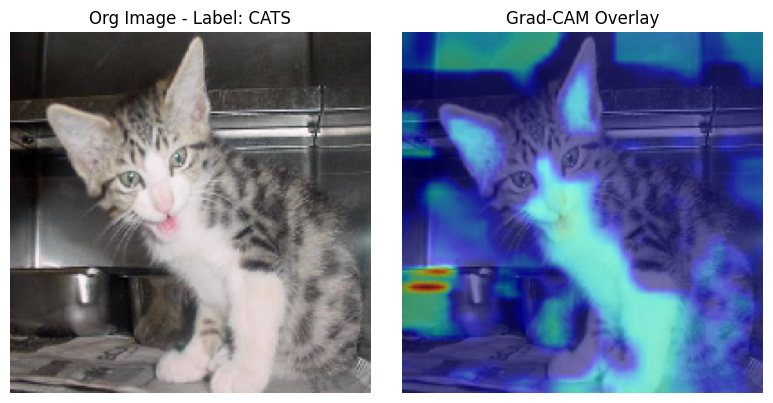

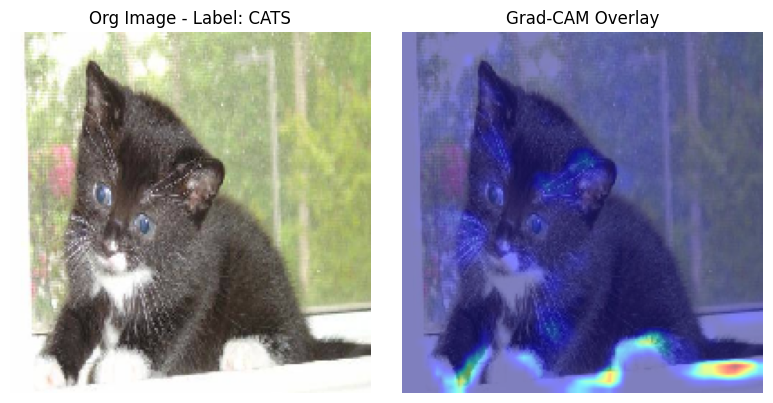

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Load all test data into memory so we can use indices like [10, 20]
print("Loading test images into memory...")
test_generator_final = test_datagen.flow_from_directory(
    'animals_small/test',
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Important: Keep order consistent
)

# Collect all batches
X_test = []
y_test = []

# Loop through the generator to get all images
for i in range(len(test_generator_final)):
    batch_x, batch_y = next(test_generator_final)
    X_test.append(batch_x)
    y_test.append(batch_y)

# Concatenate into single arrays
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# Convert one-hot labels (e.g. [0, 1, 0]) to integers (e.g. 1)
y_test_indices = np.argmax(y_test, axis=1)
class_labels = list(test_generator_final.class_indices.keys())

print(f"Loaded {len(X_test)} test images.")
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Create a model that outputs target layer activations and model predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate gradients
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Find the last conv layer name automatically
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if 'conv' in layer.name:
            return layer.name
    return None

last_conv_layer_name = get_last_conv_layer(model_cnn)
# Specific indices you asked for
image_index = [10, 20, 5, 30] 

for i in image_index:
    # 1. Get Image and Label
    image = X_test[i]
    label_idx = y_test_indices[i]
    label_name = class_labels[label_idx]
    
    # 2. Preprocess for Model (Add batch dimension)
    img_array = np.expand_dims(image, axis=0)

    # 3. Compute Heatmap
    heatmap = make_gradcam_heatmap(img_array, model_cnn, last_conv_layer_name)

    # 4. Resize heatmap to match input image (200x200)
    # We add a dimension [..., newaxis] because resize expects (H, W, C)
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], [200, 200]).numpy().squeeze()

    # 5. Plotting
    plt.figure(figsize=(8, 4))
    
    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(image) # No squeeze needed for RGB images
    plt.title(f"Org Image - Label: {label_name.upper()}")
    plt.axis('off')

    # Grad-CAM Overlay
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    # Overlay the heatmap (Jet colormap, semi-transparent)
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5) 
    plt.title("Grad-CAM Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


Visualizing a batch of pre-processed images...


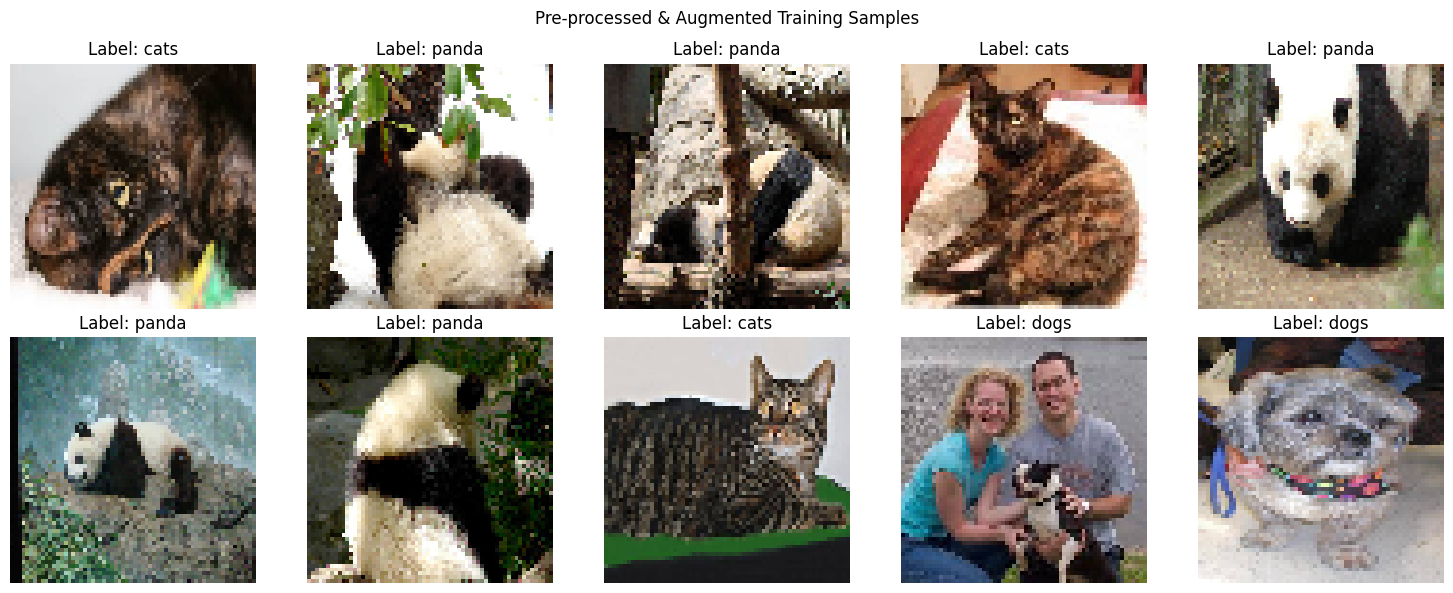

In [16]:
# ==========================================
# 4. VISUALIZATION (Sanity Check)
# ==========================================
def visualize_preprocessing(generator):
    print("\nVisualizing a batch of pre-processed images...")
    
    # Get a single batch of images and labels
    # x_batch contains the image data (numpy arrays)
    # y_batch contains the labels (one-hot encoded)
    x_batch, y_batch = next(generator)

    # Get class names from the generator
    # e.g., {0: 'cat', 1: 'dog', 2: 'panda'}
    class_indices = generator.class_indices
    class_names = list(class_indices.keys())

    # Plot the first 10 images
    plt.figure(figsize=(15, 6))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_batch[i])
        
        # Get the label name
        label_index = np.argmax(y_batch[i])
        label_name = class_names[label_index]
        
        plt.title(f"Label: {label_name}")
        plt.axis('off')
    
    plt.suptitle("Pre-processed & Augmented Training Samples")
    plt.tight_layout()
    plt.show()
visualize_preprocessing(train_generator)